## Results obtained across all datasets

In [ ]:
# Version 1.1
# Last implementation: Pareto frontier
# Refactored

data = {}
data['isic2018'] = {    #f1-mean f1-max miou-mean miou-max
    'UMergeNet':        [0.907, 0.910, 0.837, 0.842],
    'U-Net':            [0.896, 0.897, 0.820, 0.824],
    'Attention U-Net':  [0.895, 0.897, 0.819, 0.821],
    'R2Atten U-Net':    [0.900, 0.903, 0.825, 0.831],
    'UNeXt':            [0.904, 0.906, 0.832, 0.836],
    'U-Lite':           [0.907, 0.912, 0.837, 0.846],
    'DeepLabV3':        [0.911, 0.912, 0.842, 0.844],
    'YOLOv11':          [0.667, 0.667, 0.581, 0.581],
}

data['fuseg'] = {
    'UMergeNet':        [ 0.953, 0.954, 0.914, 0.916],
    'U-Net':            [ 0.956, 0.958, 0.919, 0.923],
    'Attention U-Net':  [ 0.954, 0.956, 0.917, 0.919],
    'R2Atten U-Net':    [ 0.935, 0.937, 0.886, 0.888],
    'UNeXt':            [ 0.943, 0.944, 0.897, 0.901],
    'U-Lite':           [ 0.944, 0.947, 0.900, 0.904],
    'DeepLabV3':        [ 0.891, 0.893, 0.823, 0.826],
    'YOLOv11':          [ 0.843, 0.843, 0.787, 0.787],
}
data['lars'] = {
    'UMergeNet':        [ 0.983, 0.984, 0.967, 0.968],
    'U-Net':            [ 0.984, 0.984, 0.969, 0.970],
    'Attention U-Net':  [ 0.984, 0.985, 0.969, 0.971],
    'R2Atten U-Net':    [ 0.980, 0.980, 0.961, 0.962],
    'UNeXt':            [ 0.980, 0.981, 0.961, 0.963],
    'U-Lite':           [ 0.978, 0.979, 0.958, 0.959],
    'DeepLabV3':        [ 0.968, 0.969, 0.940, 0.941],
    'YOLOv11':          [ 0.459, 0.415, 0.512, 0.508],
}
data['glas'] = {
    'UMergeNet':        [ 0.933, 0.937, 0.875, 0.881],
    'U-Net':            [ 0.927, 0.930, 0.865, 0.870],
    'Attention U-Net':  [ 0.932, 0.934, 0.873, 0.876],
    'R2Atten U-Net':    [ 0.886, 0.906, 0.796, 0.828],
    'UNeXt':            [ 0.929, 0.933, 0.868, 0.874],
    'U-Lite':           [ 0.921, 0.928, 0.854, 0.866],
    'DeepLabV3':        [ 0.860, 0.867, 0.755, 0.765],
    'YOLOv11':          [ 0.897, 0.897, 0.822, 0.822],
}


FPS = {               #GPU  CPU  
    'UMergeNet':      [1233, 34.17],
    'U-Net':          [184, 3.46],
    'Attention U-Net':[168, 3.02],
    'R2Atten U-Net':  [67.80, 1.30],
    'UNeXt':          [3529, 121],
    'U-Lite':         [1256, 27.96],
    'DeepLabV3':      [3184, 68.17],
    'YOLOv11':        [781, 602]
}

import matplotlib.pyplot as plt
import numpy as np

models = list(FPS.keys())

# Average F1-mean across datasets
f1_means = {}
for model in models:
    vals = [d[model][0] for d in data.values()]  # index 0 = F1-mean
    f1_means[model] = np.mean(vals)

# Get only f1-mean
f1_per_dataset = {}
for dataset_name in data.keys():
    f1_per_dataset[dataset_name] = {}
    for model in models:
        f1_per_dataset[dataset_name][model] = data[dataset_name][model][0]

fps_gpu = {m: FPS[m][0] for m in models}
fps_cpu = {m: FPS[m][1] for m in models}


In [85]:
# Calculating pareto frontier
def calculate_pareto_frontier(fps_dict, f1_dict, ignoring=[]):
    pareto_models = []
    for model in models:
        if model in ignoring:
            continue
        x = fps_dict[model]
        y = f1_dict[model]
        pareto = True

        for model2 in models:
            if model2 == model or model2 in ignoring:
                continue
            x2 = fps_dict[model2]
            y2 = f1_dict[model2]

            if x2 > x and y2 > y:
                pareto = False
                break

        if pareto:
            pareto_models.append(model)

    return pareto_models

print(calculate_pareto_frontier(fps_gpu, f1_means)) # pareto across all datasets
print(calculate_pareto_frontier(fps_gpu, f1_per_dataset['isic2018'])) #pareto in one dataset

['UMergeNet', 'UNeXt']
['UNeXt', 'DeepLabV3']


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


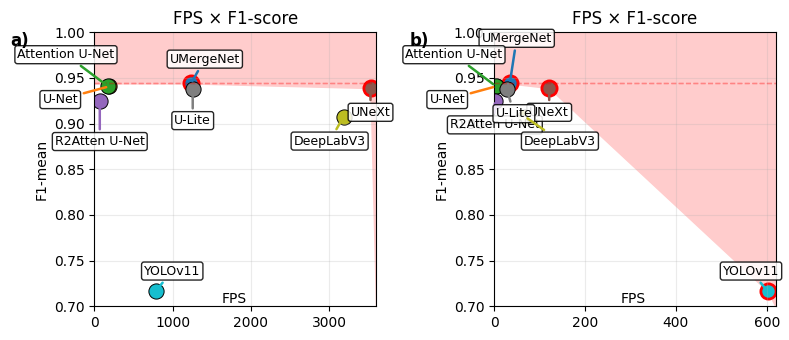

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


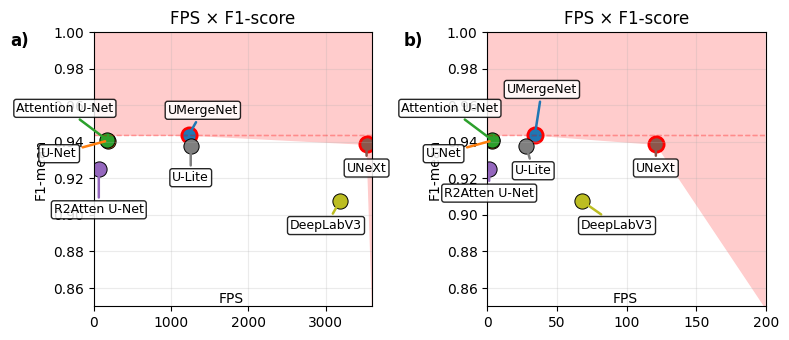

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


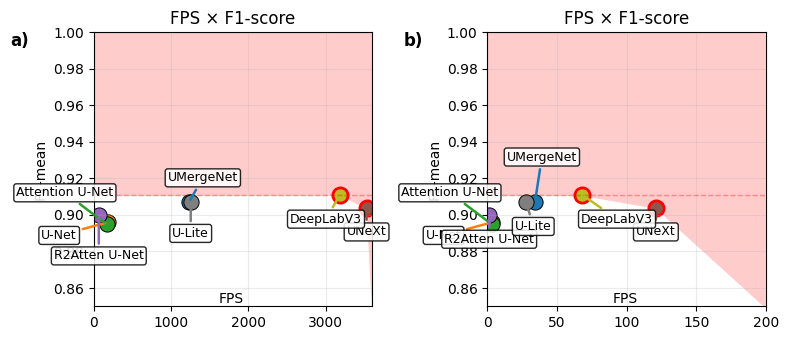

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


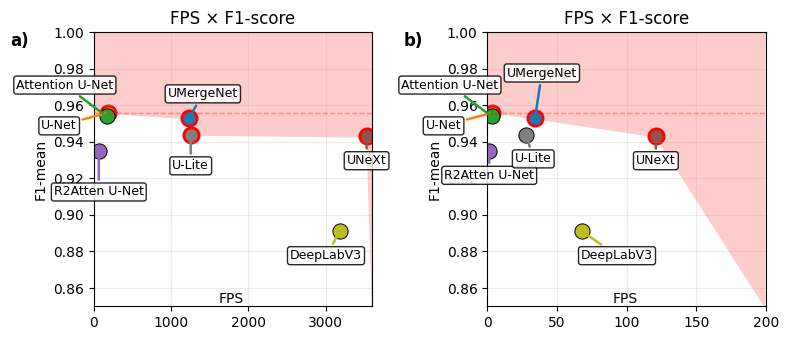

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


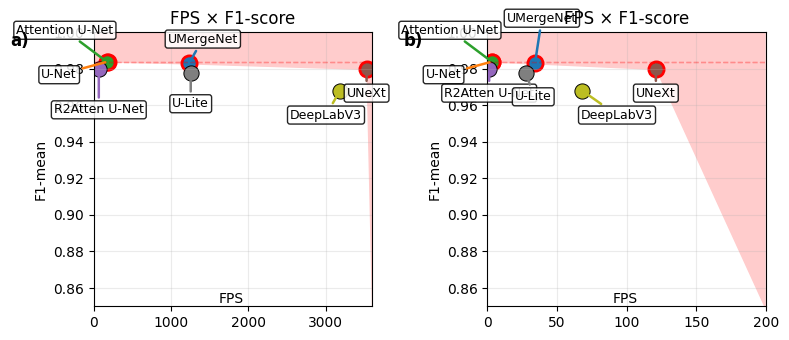

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


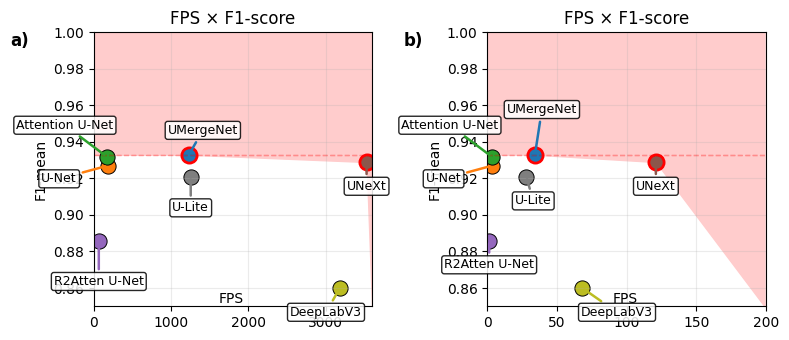

In [90]:
# -----------Set the positions manually HERE -----------
# format: ('left'/'right', 'up'/'down', dx, dy)
# If the model is not here, use default_pos
label_pos_gpu = {
    'UMergeNet':     ('right', 'up',    10, 15),
    'U-Lite':        ('right', 'down',  0, 25),
    'Attention U-Net': ('left',  'up',  30, 20),
    'U-Net':         ('left',  'down',  35, 12),
    'DeepLabV3':     ('left',  'down',  10, 20),
    'YOLOv11':       ('right', 'up',    12, 12),
    'R2Atten U-Net': ('left',  'down',  0, 32),
}

label_pos_cpu = {
    'UMergeNet':     ('right',  'up',   5, 30),
    'U-Lite':        ('right', 'down',  5, 20),
    'Attention U-Net': ('left',  'up',  30, 20),
    'U-Net':         ('left',  'down',  35, 12),
    'DeepLabV3':     ('right',  'down', 25, 20),
    'YOLOv11':       ('left', 'up',     12, 12),
    'R2Atten U-Net': ('left',  'down',  0, 20),
}

default_pos = ('right', 'up', 0, -20)
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
color_map = {model: colors[i] for i, model in enumerate(models)}


# ---------- converter helper (hor,ver,dx,dy) ----------
def compute_offset(hor, ver, dx, dy):
    dx = dx if hor == 'right' else -dx
    dy = dy if ver == 'up' else -dy
    return dx, dy


# ----------function to plot with texts ----------
def scatter_with_custom_labels(ax, fps_dict, f1_dict, title, label_map, pareto_frontier, chart_limits, ignoring=[]):
    # fixes the vertical and horizontal axis
    ax.set_ylim(chart_limits['y'][0], chart_limits['y'][1]) 
    ax.set_xlim(chart_limits['x'][0], chart_limits['x'][1])


    best_model = max(f1_dict, key=f1_dict.get)
    best_f1 = f1_dict[best_model]

    # get pareto points to draw the line
    pareto_points = [(fps_dict[m], f1_dict[m]) for m in pareto_frontier]
    # sort by FPS to draw the line perfectly
    pareto_points = sorted(pareto_points, key=lambda p: p[0])
    # draw pareto line
    pareto_x = [p[0] for p in pareto_points]
    pareto_y = [p[1] for p in pareto_points]
    
    # add a points in the limits of the chart
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    pareto_x = [xmin] + pareto_x + [xmax-1]
    pareto_y = [pareto_y[0]] + pareto_y + [ymin]
    

    ymax = ax.get_ylim()[1]
    # It draws the line, but we think that clutters the graph.
    #ax.plot(pareto_x, pareto_y, color='red', linewidth=2)
    # the zone is better for visualization
    ax.fill_between(pareto_x,pareto_y,ymax,color="#ffcccc",zorder=0) # ,alpha=0.08 alpha isn't supported to print in .eps


    for model in models:
        # ignore any model
        if model in ignoring:
            continue

        x = fps_dict[model]
        y = f1_dict[model]
        cmap_color = color_map[model]

        # Point
        if model in pareto_frontier:
            ax.scatter(x, y, color=cmap_color, s=120, edgecolor='red', linewidth=2.0)
        else:
            ax.scatter(x, y, color=cmap_color, s=120, edgecolor='black', linewidth=0.7)
        ax.axhline(best_f1, color='red', linestyle='--', linewidth=1, alpha=0.05)


        # catch pos (or default)
        hor, ver, dx, dy = label_map.get(model, default_pos)
        dx, dy = compute_offset(hor, ver, dx, dy)

        # annotation with line
        ax.annotate(
            model,
            xy=(x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85),
            arrowprops=dict(arrowstyle="-", lw=1.8, color=cmap_color),
            horizontalalignment='center'
        )

    
    ax.set_title(title)
    #Ax.set xlabel("fps")
    ax.set_ylabel("F1-mean")
    ax.grid(True, alpha=0.25)

def plot_f1_vs_fps_chart(fps_gpu, fps_cpu, f1_dict, gpu_limits, cpu_limits, mode='horizontal', savefig=None, ignoring=[]):

    if mode == 'horizontal':
        fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
    elif mode == 'vertical':
        fig, axes = plt.subplots(2, 1, figsize=(4, 6))

    gpu_pareto_frontier = calculate_pareto_frontier(fps_gpu, f1_dict, ignoring=ignoring)
    cpu_pareto_frontier = calculate_pareto_frontier(fps_cpu, f1_dict, ignoring=ignoring)

    # create the points
    ax_gpu, ax_cpu = axes
    scatter_with_custom_labels(ax_gpu,fps_gpu,f1_dict,f"FPS × F1-score",label_pos_gpu,gpu_pareto_frontier, gpu_limits, ignoring=ignoring)
    scatter_with_custom_labels(ax_cpu,fps_cpu,f1_dict,f"FPS × F1-score",label_pos_cpu,cpu_pareto_frontier, cpu_limits, ignoring=ignoring)

    # caption with colors
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=color_map[m], label=m,
                   markersize=9, markeredgecolor='black')
        for m in models
    ]

    #fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4)
    ax_gpu.text(-0.3, 1.0, "a)", transform=ax_gpu.transAxes,  fontsize=12, fontweight='bold', va='top')
    ax_cpu.text(-0.3, 1.0, "b)", transform=ax_cpu.transAxes,  fontsize=12, fontweight='bold', va='top')
    ax_gpu.text(0.45, 0.0, "FPS", transform=ax_gpu.transAxes, fontsize=10, va='bottom')
    ax_cpu.text(0.45, 0.0, "FPS", transform=ax_cpu.transAxes, fontsize=10, va='bottom')

    plt.tight_layout()
    fig.subplots_adjust(hspace=0.30)
    if savefig is not None:
        plt.savefig(savefig, format="eps", dpi=300)
    plt.show()


# first chart is a mean across all datasets
# chart scale fixed limits
gpu_limits = {'x':[0,3600], 'y':[0.7, 1.0]}
cpu_limits = {'x':[0,620],  'y':[0.7, 1.0]}
plot_f1_vs_fps_chart(fps_gpu, fps_cpu, f1_means, gpu_limits, cpu_limits, savefig="f1mean_vs_fps_h.eps")

# ignore yolo to improve the visualization
# chart scale fixed limits
gpu_limits = {'x':[0,3600], 'y':[0.85, 1.0]}
cpu_limits = {'x':[0,200],  'y':[0.85, 1.0]}

plot_f1_vs_fps_chart(fps_gpu, fps_cpu, f1_means, gpu_limits, cpu_limits, ignoring='YOLOv11', savefig="f1mean_vs_fps_h_noyolo.eps")

plot_f1_vs_fps_chart(fps_gpu, fps_cpu, f1_per_dataset['isic2018'], gpu_limits, cpu_limits, ignoring='YOLOv11', savefig="f1mean_vs_fps_isic2018_noyolo.eps")

plot_f1_vs_fps_chart(fps_gpu, fps_cpu, f1_per_dataset['fuseg'], gpu_limits, cpu_limits, ignoring='YOLOv11', savefig="f1mean_vs_fps_fuseg_noyolo.eps")

plot_f1_vs_fps_chart(fps_gpu, fps_cpu, f1_per_dataset['lars'], gpu_limits, cpu_limits, ignoring='YOLOv11', savefig="f1mean_vs_fps_lars_noyolo.eps")

plot_f1_vs_fps_chart(fps_gpu, fps_cpu, f1_per_dataset['glas'], gpu_limits, cpu_limits, ignoring='YOLOv11', savefig="f1mean_vs_fps_glas_noyolo.eps")